In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
import os
os.chdir("/Users/miguel.vidal_ladivin/Desktop")

In [47]:
df = pd.read_excel("Mexico GDP.xlsx")



In [49]:
df.head()

,Periodo,GDP
0,1960,1.304000e+10
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10


In [51]:
df.describe()

,Periodo,GDP
count,62.000000,6.200000e+01
mean,1990.500000,4.866155e+11
std,18.041619,4.544804e+11
min,1960.000000,1.304000e+10
25%,1975.250000,8.336062e+10
50%,1990.500000,2.885511e+11
75%,2005.750000,8.944031e+11
max,2021.000000,1.315351e+12


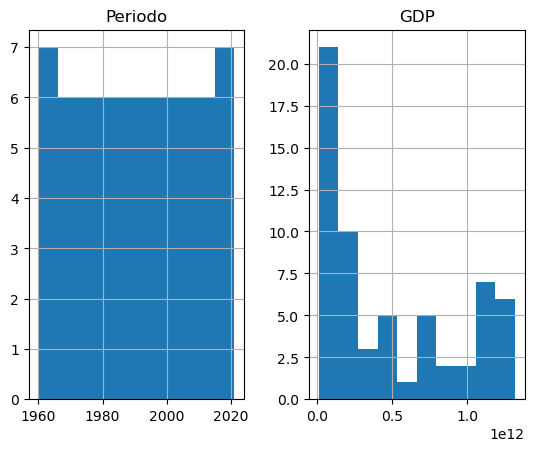

In [53]:
viz = df[["Periodo", "GDP"]]
viz.hist()
plt.show()

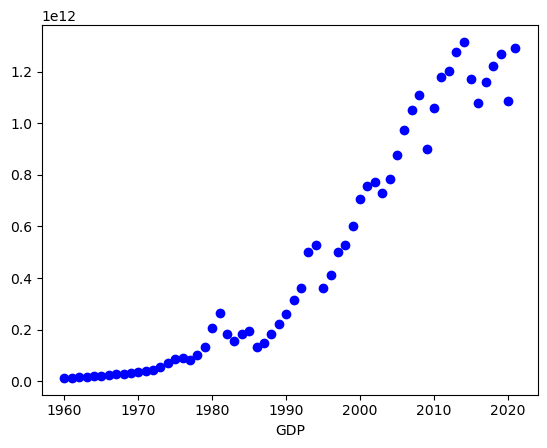

In [54]:
plt.scatter(df.Periodo, df.GDP, color="blue")
plt.xlabel("Periodo")
plt.xlabel("GDP")
plt.show()

In [56]:
msk = np.random.rand(len(df)) <= .80       #variable para definir grupos de entrenamiento y prueba

In [59]:
train = df[msk]   #Grupo de entrenamiento
train

,Periodo,GDP
0,1960,1.304000e+10
5,1965,2.184000e+10
6,1966,2.432000e+10
7,1967,2.656000e+10
8,1968,2.936000e+10
9,1969,3.248000e+10
10,1970,3.552000e+10
11,1971,3.920000e+10
12,1972,4.520000e+10
14,1974,7.200000e+10


In [61]:
test = df[~msk]  #Grupo de prueba
test

,Periodo,GDP
1,1961,1.416000e+10
2,1962,1.520000e+10
3,1963,1.696000e+10
4,1964,2.008000e+10
13,1973,5.528000e+10
19,1979,1.345614e+11
21,1981,2.639593e+11
25,1985,1.952198e+11
27,1987,1.475407e+11
34,1994,5.278132e+11


In [63]:
#Convertir en arreglo la X y la Y tomando en cuenta que son flotantes
train_x = np.asanyarray(train[["Periodo"]]).flatten()
train_y = np.asanyarray(train[["GDP"]]).flatten()


In [65]:
# Ajustar los datos al modelo logistico
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split

def modelo_logistico(x, beta1, beta2):   #Funcion del modelo logistico
        return 1 / (1 + np.exp(-(beta1 * x + beta2)))

popt, pov = curve_fit(modelo_logistico, train_x, train_y)  #Ajuste

C:\Users\miguel.vidal_ladivin\AppData\Local\Temp\ipykernel_20388\25318621.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pov = curve_fit(modelo_logistico, train_x, train_y)


In [67]:
print(popt)  #Poca estabilidad numerica, con estos coeficientes es complicado continuar.

[1. 1.]


In [69]:
#Se normalizan los datos de ambas variables
df['GDP_normalizado'] = df['GDP'] / df['GDP'].max()

df['Periodo_normalizado'] = df['Periodo'] / df['Periodo'].max()

print(df.head())


   Periodo           GDP  GDP_normalizado  Periodo_normalizado
0     1960  1.304000e+10         0.009914             0.969817
1     1961  1.416000e+10         0.010765             0.970312
2     1962  1.520000e+10         0.011556             0.970807
3     1963  1.696000e+10         0.012894             0.971301
4     1964  2.008000e+10         0.015266             0.971796


In [71]:
msk = np.random.rand(len(df)) <= .80

In [73]:
train = df[msk]
train

,Periodo,GDP,GDP_normalizado,Periodo_normalizado
0,1960,1.304000e+10,0.009914,0.969817
1,1961,1.416000e+10,0.010765,0.970312
2,1962,1.520000e+10,0.011556,0.970807
4,1964,2.008000e+10,0.015266,0.971796
5,1965,2.184000e+10,0.016604,0.972291
6,1966,2.432000e+10,0.018489,0.972786
7,1967,2.656000e+10,0.020192,0.973281
8,1968,2.936000e+10,0.022321,0.973775
9,1969,3.248000e+10,0.024693,0.974270
11,1971,3.920000e+10,0.029802,0.975260


In [75]:
test = df[~msk]
test

,Periodo,GDP,GDP_normalizado,Periodo_normalizado
3,1963,1.696000e+10,0.012894,0.971301
10,1970,3.552000e+10,0.027004,0.974765
17,1977,8.181416e+10,0.062199,0.978229
21,1981,2.639593e+11,0.200676,0.980208
23,1983,1.561592e+11,0.118721,0.981197
33,1993,5.007361e+11,0.380686,0.986145
40,2000,7.079067e+11,0.538188,0.989609
55,2015,1.171868e+12,0.890916,0.997031
58,2018,1.222408e+12,0.929340,0.998516


In [77]:
# Grupos de entrenamiento y prueba normalizados
train_x = np.asanyarray(train[["Periodo_normalizado"]]).flatten()
train_y = np.asanyarray(train[["GDP_normalizado"]]).flatten()
test_x = np.asanyarray(test[["Periodo_normalizado"]]).flatten()
test_y = np.asanyarray(test[["GDP_normalizado"]]).flatten()

In [89]:
# Ajuste de los datos normalizados al modelo logistico.
def modelo_logistico(x, beta1, beta2):
        return 1 / (1 + np.exp(-(beta1 * x + beta2)))

popt, pov = curve_fit(modelo_logistico, train_x, train_y)

print (popt)

[ 282.23957801 -279.25148003]


In [91]:
#Predicción del modelo con datos de prueba
y_hat = modelo_logistico(test_x, *popt)


In [93]:
from sklearn.metrics import r2_score
print (" Mean absolute error : %.2f" % np.mean(np.absolute(y_hat - test_y)))
#calcular el valor absoluto que es yhat - y
print ("Residual sum of squares (MSE): %.2f" % np.mean((y_hat - test_y) ** 2))
#suma de residuales al cuadrado, suma promedio d ela diferencia entre las aproximaciones entre yhat y Y al cuadrado
print ("R2-score: %.2f" % r2_score(y_hat , test_y))
#Valor aproximado y valor real

 Mean absolute error : 0.04
Residual sum of squares (MSE): 0.00
R2-score: 0.97


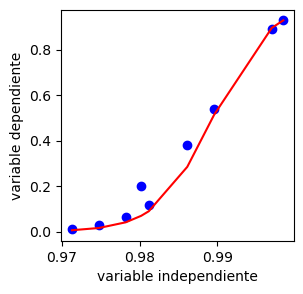

In [144]:
plt.figure(figsize=(3, 3))
plt.plot(test_x, test_y, "bo")
plt.plot(test_x, y_hat, "r")
plt.ylabel("variable dependiente")
plt.xlabel("variable independiente")
plt.show()

In [146]:
# Pronostico del año 2022 sin normalizar 2022
year_2022 = 2022
gdp_2022 = modelo_logistico(year_2022, *popt)
print(f"Pronóstico del PIB para 2022 (original): {gdp_2022}")

Pronóstico del PIB para 2022 (original): 1.0


In [148]:
#Normalizar el año 2022
year_2022_normalized = year_2022 / df['Periodo'].max()

In [158]:
# Pronostico 2022 normalizado
year_2022_norm = 2022 / df['Periodo'].max()
gdp_2022_norm = modelo_logistico(year_2022_norm, *popt)
print(f"Pronóstico del PIB para 2022 (normalizado): {gdp_2022_norm}")


Pronóstico del PIB para 2022 (normalizado): 0.9580230593073872


In [162]:
# Pronostico 2022 sin normalizar
gdp_2022_final = gdp_2022_norm * df['GDP'].max()
print(f"Pronóstico del PIB para 2022 (normalizado y desnormalizado): {gdp_2022_final}")

Pronóstico del PIB para 2022 (normalizado y desnormalizado): 1260136764903.7761
